# Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
from pettingzoo.mpe import simple_spread_v3
import random

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: De

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Replay Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, obs, actions, rewards, next_obs, dones):
        experience = (obs, actions, rewards, next_obs, dones)
        self.memory.append(experience)

    def sample(self):

        #Random sample from the buffer
        experiences = random.sample(self.memory, self.batch_size)

        #To tensors
        obs = torch.tensor(np.array([e[0] for e in experiences]), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array([e[1] for e in experiences]), dtype=torch.float32, device=device)
        rewards = torch.tensor(np.array([e[2] for e in experiences]), dtype=torch.float32, device=device)
        next_obs = torch.tensor(np.array([e[3] for e in experiences]), dtype=torch.float32, device=device)
        dones = torch.tensor(np.array([e[4] for e in experiences]), dtype=torch.float32, device=device)

        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.memory)

# Actor

In [5]:
class Actor(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, obs):
        x = F.relu(self.fc1(obs))
        x = F.relu(self.fc2(x))
        return torch.sigmoid(self.fc3(x))

# Critic

In [6]:
class Critic(nn.Module):
    def __init__(self, total_obs_dim, total_action_dim):
        super().__init__()
        self.fc1 = nn.Linear(total_obs_dim + total_action_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, obs_all, actions_all):
        x = torch.cat([obs_all, actions_all], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Agent

In [7]:
class Agent:
    def __init__(self, obs_dim, action_dim, total_obs_dim, total_action_dim, actor_lr=1e-3, critic_lr=1e-3):
        self.actor = Actor(obs_dim, action_dim).to(device)
        self.actor_target = Actor(obs_dim, action_dim).to(device)

        self.critic = Critic(total_obs_dim, total_action_dim).to(device)
        self.critic_target = Critic(total_obs_dim, total_action_dim).to(device)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

# Soft update

In [8]:
def soft_update(net, target_net, tau):
    #Soft update the target network for learning stability
    for param, target_param in zip(net.parameters(), target_net.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

# Environment

In [9]:
env = simple_spread_v3.parallel_env(N=3,local_ratio=0.5,max_cycles=25,continuous_actions=True)
env.reset(seed=SEED)

agents = env.agents
num_agents = len(agents)

obs_dims = []
act_dims = []
for agent in agents:
    obs_dims.append(env.observation_space(agent).shape[0])
    act_dims.append(env.action_space(agent).shape[0])

total_obs_dim = sum(obs_dims)
total_action_dim = sum(act_dims)


error: XDG_RUNTIME_DIR not set in the environment.


# Initialize Agents

In [10]:
MADDPG_agents = []

for i in range(num_agents):
    agent = Agent(obs_dim=obs_dims[i],action_dim=act_dims[i],total_obs_dim=total_obs_dim,total_action_dim=total_action_dim)
    MADDPG_agents.append(agent)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Exploration Noise

In [11]:
#Adding noise during training to encourage exploration
class GaussianNoise:
    def __init__(self, size, std=0.2):
        self.std = std
        self.size = size

    def sample(self):
        return np.random.normal(0, self.std, self.size)
        
noise_processes = [GaussianNoise(act_dims[i]) for i in range(num_agents)]

# Hyperparameters

In [12]:
BUFFER_SIZE = int(10e6)
BATCH_SIZE = 1024
GAMMA = 0.95
TAU = 0.01
LEARNING_STARTS = 1024
UPDATE_EVERY = 100

# Replay buffer init

In [13]:
replay_buffer = ReplayBuffer(BUFFER_SIZE, BATCH_SIZE)

# Action Selection

In [14]:
def select_actions(obs_dict, noise=True):
    actions = []
    for i, agent in enumerate(MADDPG_agents):
        #Observation to tensor(Oi)
        obs = torch.tensor(obs_dict[agents[i]],dtype=torch.float32,device=device).unsqueeze(0)
        #Forward pass through the actor network to get action(μθ(Oi))
        action = agent.actor(obs).detach().cpu().numpy()[0]
        #Adding noise(μθ(Oi)+Nt)
        if noise:
            action += noise_processes[i].sample()
        #Clip action to [0,1]
        action = np.clip(action, 0.0, 1.0)
        actions.append(action)

    return actions

# Training Step

In [15]:
def train_step():
    
    #Checks if there are enough data in the replay buffer
    if len(replay_buffer) < BATCH_SIZE:
        return

    #Random sample from the replay buffer and joint tensors
    obs, actions, rewards, next_obs, dones = replay_buffer.sample()
    obs_all = obs.view(BATCH_SIZE, -1)
    #x^{ij}
    next_obs_all = next_obs.view(BATCH_SIZE, -1)
    actions_all = actions.view(BATCH_SIZE, -1)

    #Computes target actions(α'κ = μ'κ(o^{j}k))
    next_actions = []
    for i, agent in enumerate(MADDPG_agents):
        next_obs_i = next_obs[:, i, :]
        next_action_i = agent.actor_target(next_obs_i)
        next_actions.append(next_action_i)

    #All the actions(a'1,...,a'n)
    next_actions_all = torch.cat(next_actions, dim=-1)

    #Updates every critic(y^{j}=r^{j}i+γQ^{μ'}i(x'j,a'1,...a'n))|a'k=μ'k(o^{j}k))
    for i, agent in enumerate(MADDPG_agents):
        with torch.no_grad():
            y = rewards[:, i].unsqueeze(1) + GAMMA * agent.critic_target(next_obs_all, next_actions_all)

        critic_value = agent.critic(obs_all, actions_all)
        critic_loss = F.mse_loss(critic_value, y)

        agent.critic_optimizer.zero_grad()
        critic_loss.backward()
        agent.critic_optimizer.step()

    #Updates every actor
    for i, agent in enumerate(MADDPG_agents):
        current_actions = []
        #grad(aiQ^{μ}i(x^{j},a^{j}1,...,a^{j}n))
        for j, other_agent in enumerate(MADDPG_agents):
            obs_j = obs[:, j, :]
            if j == i:
                current_actions.append(agent.actor(obs_j))
            else:
                current_actions.append(other_agent.actor(obs_j).detach())
       
        #updates actor using the sampled policy gradient
        actions_all_pred = torch.cat(current_actions, dim=-1)
        actor_loss = -agent.critic(obs_all, actions_all_pred).mean()

        agent.actor_optimizer.zero_grad()
        actor_loss.backward()
        agent.actor_optimizer.step()

    #Soft updates target networks(θ'i <- τθi+(1-τ)θ'i))
    for agent in MADDPG_agents:
        soft_update(agent.actor, agent.actor_target, TAU)
        soft_update(agent.critic, agent.critic_target, TAU)

# Training Loop

In [16]:
num_episodes = 25000
episode_rewards = []
for episode in range(num_episodes):
    obs, infos = env.reset()
    episode_reward = np.zeros(num_agents)

    step = 0
    while True:
        #Actions selection
        actions = select_actions(obs)
        actions_dict = {agent: actions[i] for i, agent in enumerate(agents)}
        
        next_obs, rewards, terminations, truncations, infos = env.step(actions_dict)
        
        #Termination condition
        dones = [terminations[a] or truncations[a] for a in agents]

        #Replay buffer save
        replay_buffer.add(
            obs=[obs[a] for a in agents],
            actions=actions,
            rewards=[rewards[a] for a in agents],
            next_obs=[next_obs[a] for a in agents],
            dones=dones)
        
        obs = next_obs
        #Computes reward
        episode_reward += np.array([rewards[a] for a in agents])

        #Train step every UPDATE_EVERY steps and after there are enough data to the replay buffer
        if len(replay_buffer) > LEARNING_STARTS and step % UPDATE_EVERY == 0:
            train_step()

        step += 1
        if all(dones):
            break

    episode_rewards.append(episode_reward)
    if episode % 100 == 0:
        print(f"Episode {episode}, rewards: {episode_reward}")

Episode 0, rewards: [-25.17380464 -26.67380464 -26.67380464]
Episode 100, rewards: [-24.7755609 -25.2755609 -25.2755609]
Episode 200, rewards: [-28.39430292 -28.39430292 -28.39430292]
Episode 300, rewards: [-19.55508677 -19.55508677 -19.55508677]
Episode 400, rewards: [-28.48009552 -28.48009552 -28.48009552]
Episode 500, rewards: [-29.99312721 -29.49312721 -30.49312721]
Episode 600, rewards: [-24.68795189 -24.18795189 -24.68795189]
Episode 700, rewards: [-21.56282139 -21.56282139 -21.56282139]
Episode 800, rewards: [-20.38704736 -20.38704736 -20.38704736]
Episode 900, rewards: [-21.05639266 -21.05639266 -21.05639266]
Episode 1000, rewards: [-14.38951646 -14.38951646 -14.38951646]
Episode 1100, rewards: [-12.97601853 -12.97601853 -10.47601853]
Episode 1200, rewards: [-22.09046203 -22.09046203 -19.59046203]
Episode 1300, rewards: [-18.60026844 -18.60026844 -16.60026844]
Episode 1400, rewards: [-19.54306776 -18.04306776 -19.04306776]
Episode 1500, rewards: [-17.91038979 -17.91038979 -16.9

# Plot

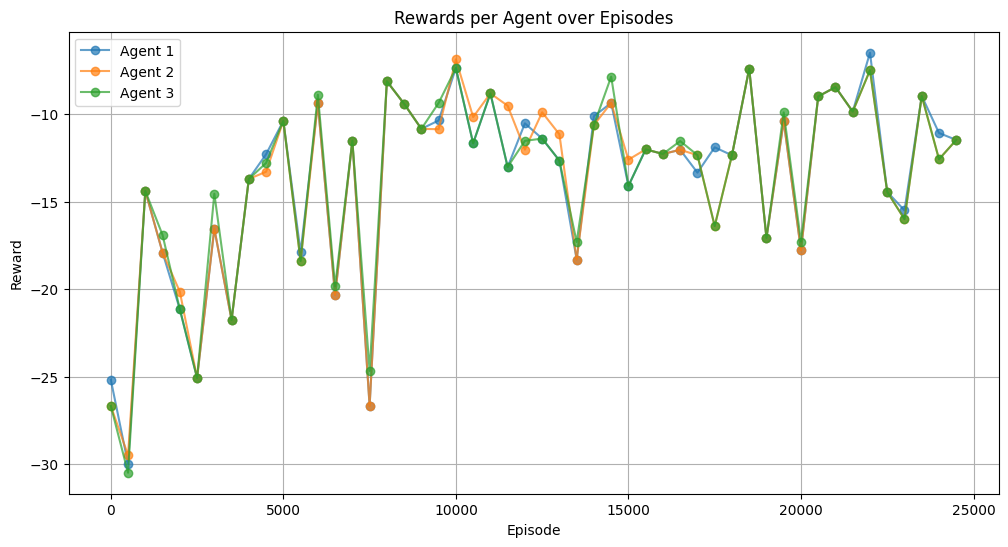

In [17]:
episode_rewards_array = np.array(episode_rewards)

num_episodes = episode_rewards_array.shape[0]
num_agents = episode_rewards_array.shape[1]

step = 500
episodes = np.arange(0, num_episodes, step)
rewards_sampled = episode_rewards_array[::step]

plt.figure(figsize=(12, 6))

for i in range(num_agents):
    plt.plot(episodes, rewards_sampled[:, i], marker='o', label=f'Agent {i+1}', alpha=0.7)

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Rewards per Agent over Episodes')
plt.legend()
plt.grid(True)
plt.show()


# Evaluation

In [18]:
def evaluate_policy(env, agents_maddpg, n_episodes=1000):
    eval_rewards = []
    for ep in range(n_episodes):
        obs, infos = env.reset()
        episode_reward = np.zeros(num_agents)

        while True:
            #Selects actions without exploration noise
            actions = select_actions(obs, noise=False)
            actions_dict = {agent: actions[i] for i, agent in enumerate(agents)}

            next_obs, rewards, terminations, truncations, infos = env.step(actions_dict)

            dones = [terminations[a] or truncations[a] for a in agents]

            episode_reward += np.array([rewards[a] for a in agents])
            obs = next_obs

            if all(dones):
                break

        eval_rewards.append(episode_reward)

    eval_rewards = np.array(eval_rewards)
    mean_reward = eval_rewards.mean(axis=0)
    std_reward = eval_rewards.std(axis=0)

    return mean_reward, std_reward

mean_eval, std_eval = evaluate_policy(env, agents)
print("Evaluation results:")
for i in range(num_agents):
    print(f"Agent {i}: mean reward = {mean_eval[i]:.2f}, std = {std_eval[i]:.2f}")

Evaluation results:
Agent 0: mean reward = -10.82, std = 3.30
Agent 1: mean reward = -10.85, std = 3.25
Agent 2: mean reward = -10.84, std = 3.25
